<a href="https://colab.research.google.com/github/Siam19-ai/MachineLearning/blob/main/Forecasting(Normal%20linear%20regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Siam19-ai/MachineLearning.git

Cloning into 'MachineLearning'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 87.32 KiB | 4.37 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [8]:
df=pd.read_csv("/content/MachineLearning/Food Delivery Dataset.csv")

In [9]:
df['new_created_at'] = pd.to_datetime(df['created_at'])
df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

/tmp/ipykernel_399/3261693086.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_created_at'] = pd.to_datetime(df['created_at'])
/tmp/ipykernel_399/3261693086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


In [10]:
df.isnull().sum()

,0
market_id,3
store_primary_category,26
order_protocol,3
total_items,0
subtotal,0
min_item_price,0
max_item_price,0
total_onshift_partners,80
total_busy_partners,80
total_outstanding_orders,80


In [12]:
df = df.sort_values("new_created_at").reset_index(drop=True)

df["delivery_time_minutes"] = (
    (df["new_actual_delivery_time"] - df["new_created_at"])
    .dt.total_seconds() / 60
)
df = df[df["delivery_time_minutes"] >= 0]

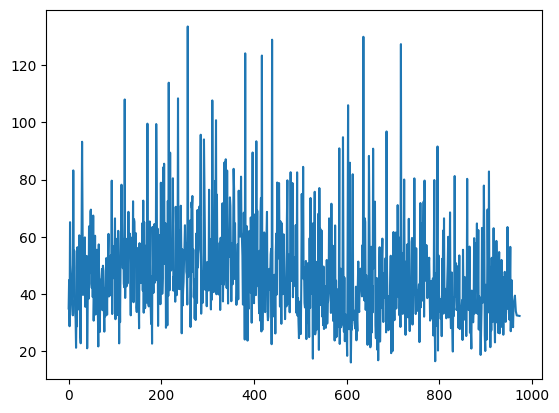

In [13]:
plt.plot(df["delivery_time_minutes"], linestyle ="solid")
plt.show()

In [14]:
df["delivery_time_minutes"].index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       953, 954, 956, 957, 959, 960, 963, 965, 967, 973],
      dtype='int64', length=962)

**FORECASTING**

In [ ]:
y=df["delivery_time_minutes"]

In [16]:
features = [
    "total_items",
    "subtotal",
    "min_item_price",
    "max_item_price",
    "total_onshift_partners",
    "total_busy_partners",
    "total_outstanding_orders",
    "created_day",
    "created_holiday"
]

X = df[features]

print(X)

     total_items  subtotal  min_item_price  max_item_price  \
0              7      9208             679            1679   
1              4      2040             142             813   
2              4      1690             295             795   
3              7      4200             350            1050   
4              2      1850             650             850   
..           ...       ...             ...             ...   
960            2      1399             499             900   
963            1      2015            1425            1425   
965            2      2998            1499            1499   
967            4      3530             695             795   
973            2      1500             400            1100   

     total_onshift_partners  total_busy_partners  total_outstanding_orders  \
0                      63.0                 45.0                      49.0   
1                      15.0                 14.0                      17.0   
2                    

In [17]:
df_model = df[features + ["delivery_time_minutes"]].dropna()

X = df_model[features]
y = df_model["delivery_time_minutes"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

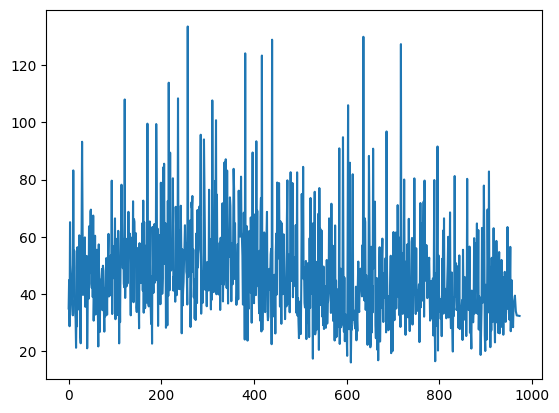

In [23]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Identify categorical columns
categorical_features = ["created_day", "created_holiday"]

# Apply one-hot encoding to X_train and X_test
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

model = LinearRegression()
model.fit(X_train_encoded, y_train)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_encoded)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.17759747124727177
MSE: 227.9183006243715
